In [1]:
#import Libraries
import cv2
import matplotlib.pyplot as plt
import numpy as np
print("all libraries imported")

all libraries imported


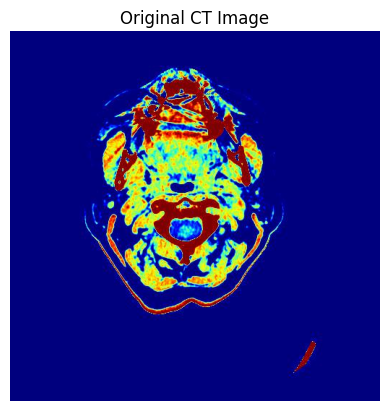

In [2]:
#declare file path and Load One CT Image
image = cv2.imread("/kaggle/input/datasets/shuvokumarbasakbd/brain-ct-medical-imaging-colorized-dataset/Computed Tomography (CT) of the Brain/dataset/test/aneurysm/1_10.jpg")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Original CT Image")
plt.axis("off")
plt.show()

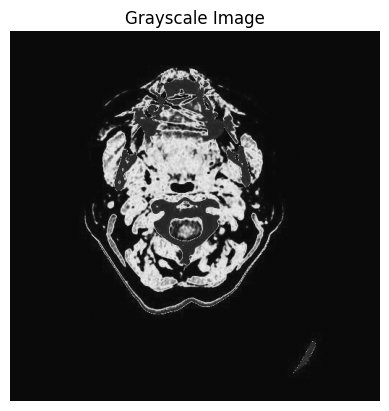

In [3]:
#convert selected image to greyscale
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

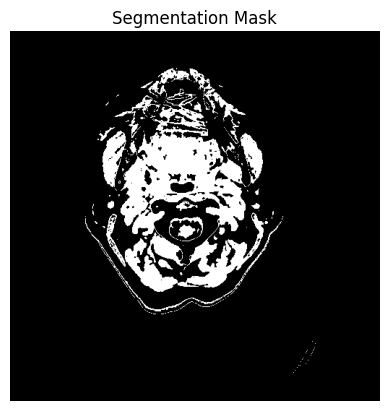

In [4]:
#Segment the image  Using Otsu Threshold
_, mask = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.imshow(mask, cmap="gray")
plt.title("Segmentation Mask")
plt.axis("off")
plt.show()

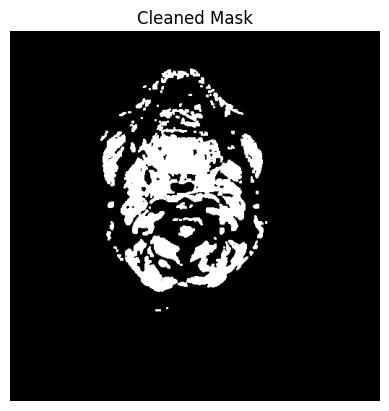

In [5]:
#Remove Small Noise
kernel = np.ones((3,3), np.uint8)

mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

plt.imshow(mask, cmap="gray")
plt.title("Cleaned Mask")
plt.axis("off")
plt.show()

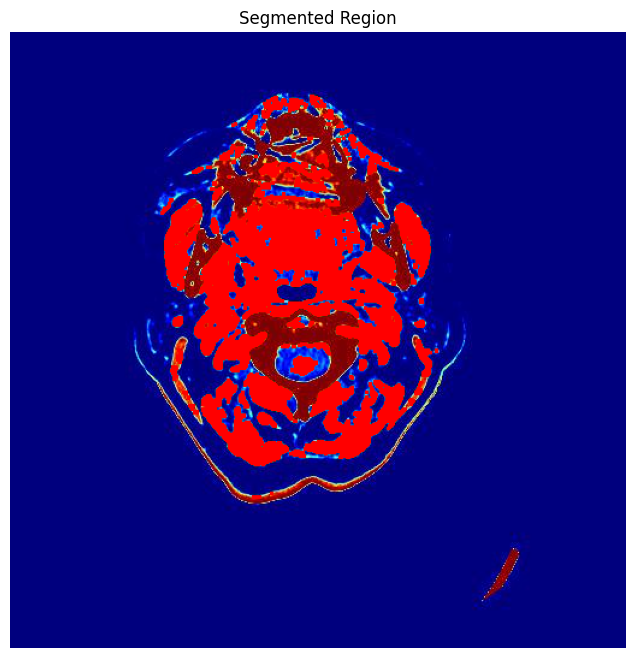

In [6]:
#Overlay the Segmentation mask on the actual image 
overlay = image.copy()

overlay[mask == 255] = [255,0,0]

plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.title("Segmented Region")
plt.axis("off")
plt.show()

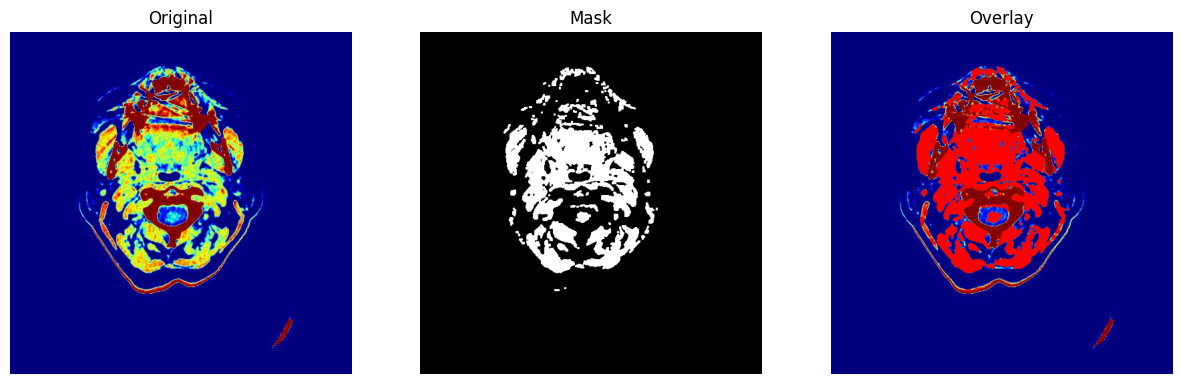

In [7]:
#side by side display of the original image, segmented mask and overlay
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()

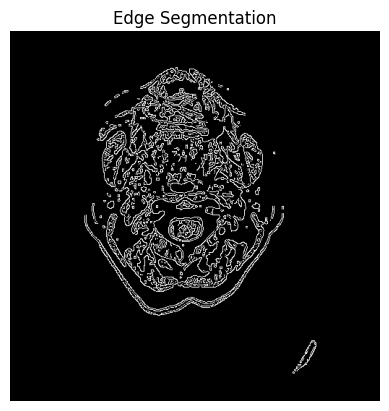

In [8]:
#Edge-Based Segmentation
edges = cv2.Canny(gray, 80, 150)

plt.imshow(edges, cmap="gray")
plt.title("Edge Segmentation")
plt.axis("off")
plt.show()